In [1]:
pip install yfinance pandas numpy matplotlib seaborn scikit-learn xgboost shap backtrader tensorflow transformers kagglehub

  Using cached tensorflow-2.20.0-cp311-cp311-win_amd64.whl.metadata (4.6 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached ml_dtypes-0.5.4-cp311-cp311-win_amd64.whl.metadata (9.2 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.19.0-cp311-cp311-win_amd64.whl.metadata (35 kB)
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------

# Assignment 2 (Version 2 — Demo-Based): Feature Engineering, ML Models & Sentiment Analysis

This version follows the implementation patterns from the course demo notebooks:
- **MLP**: TensorFlow/Keras Sequential API (Demo 17)
- **LSTM**: TensorFlow/Keras with 50-day lookback (Demo 18)
- **Transformer**: Custom Time2Vector + MultiHeadAttention (Demo 19)
- **Feature Selection**: RFECV — Recursive Feature Elimination with Cross-Validation (Demo 16)
- **SHAP**: TreeExplainer with waterfall plots (Demo 16)
- **Sentiment**: Raw AutoTokenizer + AutoModel inference (Demo 20)

**Differences from Version 1:**

| Aspect | Version 1 | Version 2 (this notebook) |
|--------|-----------|--------------------------|
| MLP framework | sklearn MLPClassifier | TensorFlow/Keras |
| LSTM framework | PyTorch | TensorFlow/Keras |
| Transformer | Not included | Included (4th model) |
| Feature Selection | MI + XGBoost importance union | RFECV |
| SHAP visualization | Summary plot only | Summary + Waterfall |
| Sentiment inference | `pipeline()` wrapper | Raw tokenizer + model |
| LSTM lookback | 10 days | 50 days |
| Training visualization | Minimal | Accuracy/loss curves |

## Step 0: Data Download

Same as Version 1 — download AAPL daily OHLCV data (2020–2025).

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.feature_selection import RFECV
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

TICKER = "AAPL"
INITIAL_CAPITAL = 10000

raw = yf.download(TICKER, start="2020-01-01", end="2025-12-31")
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
raw.index = pd.to_datetime(raw.index)
if raw.index.tz is not None:
    raw.index = raw.index.tz_localize(None)

print(f"Downloaded {len(raw)} trading days for {TICKER}")
print(f"Date range: {raw.index[0].date()} to {raw.index[-1].date()}")
raw.tail()

[*********************100%***********************]  1 of 1 completed

Downloaded 1507 trading days for AAPL
Date range: 2020-01-02 to 2025-12-30


Price,Close,High,Low,Open,Volume
Date,,,,,
2025-12-23,272.105377,272.245261,269.308007,270.586809,29642000
2025-12-24,273.554016,275.172497,271.945536,272.085389,17910600
2025-12-26,273.144409,275.112569,272.604905,273.903708,21521800
2025-12-29,273.504089,274.103504,272.095404,272.435082,23715200
2025-12-30,272.824707,273.823772,272.025467,272.554970,22139600


## 1. Feature Engineering: Alpha158

Same Alpha158 implementation as Version 1 — 134 technical factors from OHLCV.

In [3]:
def compute_alpha158(df):
    close = df['Close'].astype(float)
    open_ = df['Open'].astype(float)
    high = df['High'].astype(float)
    low = df['Low'].astype(float)
    volume = df['Volume'].astype(float)

    features = pd.DataFrame(index=df.index)
    hl = high - low + 1e-12

    features['KMID']  = (close - open_) / open_
    features['KLEN']  = (high - low) / open_
    features['KMID2'] = (close - open_) / hl
    features['KUP']   = (high - np.maximum(open_, close)) / open_
    features['KUP2']  = (high - np.maximum(open_, close)) / hl
    features['KLOW']  = (np.minimum(open_, close) - low) / open_
    features['KLOW2'] = (np.minimum(open_, close) - low) / hl
    features['KSFT']  = (2 * close - high - low) / open_
    features['KSFT2'] = (2 * close - high - low) / hl

    ret = close.pct_change()
    pos_ret = (ret > 0).astype(float)
    neg_ret = (ret < 0).astype(float)
    abs_ret = ret.abs()
    vol_pct = volume.pct_change()
    windows = [5, 10, 20, 30, 60]

    for d in windows:
        features[f'ROC_{d}']  = close / close.shift(d) - 1
        features[f'MA_{d}']   = close.rolling(d).mean() / close
        features[f'STD_{d}']  = close.rolling(d).std() / close
        features[f'MAX_{d}']  = close.rolling(d).max() / close
        features[f'MIN_{d}']  = close.rolling(d).min() / close
        features[f'QTLU_{d}'] = close.rolling(d).quantile(0.8) / close
        features[f'QTLD_{d}'] = close.rolling(d).quantile(0.2) / close
        r_max = close.rolling(d).max()
        r_min = close.rolling(d).min()
        features[f'RSV_{d}'] = (close - r_min) / (r_max - r_min + 1e-12)
        features[f'IMAX_{d}'] = close.rolling(d).apply(np.argmax, raw=True) / d
        features[f'IMIN_{d}'] = close.rolling(d).apply(np.argmin, raw=True) / d
        features[f'IMXD_{d}'] = features[f'IMAX_{d}'] - features[f'IMIN_{d}']
        features[f'CORR_{d}'] = close.rolling(d).corr(volume)
        features[f'CORD_{d}'] = ret.rolling(d).corr(vol_pct)
        features[f'CNTP_{d}'] = pos_ret.rolling(d).sum() / d
        features[f'CNTN_{d}'] = neg_ret.rolling(d).sum() / d
        features[f'CNTD_{d}'] = features[f'CNTP_{d}'] - features[f'CNTN_{d}']
        features[f'SUMP_{d}'] = ret.clip(lower=0).rolling(d).sum()
        features[f'SUMN_{d}'] = ret.clip(upper=0).rolling(d).sum()
        features[f'SUMD_{d}'] = features[f'SUMP_{d}'] - features[f'SUMN_{d}']
        features[f'VMA_{d}']   = volume.rolling(d).mean() / (volume + 1e-12)
        features[f'VSTD_{d}']  = volume.rolling(d).std() / (volume + 1e-12)
        features[f'WVMA_{d}']  = (abs_ret * volume).rolling(d).std() / (volume.rolling(d).mean() + 1e-12)
        features[f'VSUMP_{d}'] = (volume * pos_ret).rolling(d).sum() / (volume.rolling(d).sum() + 1e-12)
        features[f'VSUMN_{d}'] = (volume * neg_ret).rolling(d).sum() / (volume.rolling(d).sum() + 1e-12)
        features[f'VSUMD_{d}'] = features[f'VSUMP_{d}'] - features[f'VSUMN_{d}']
    return features

features = compute_alpha158(raw)
print(f"Computed {features.shape[1]} Alpha158 features")

Computed 134 Alpha158 features


### Target Variable & Train/Test Split

Same as Version 1 — binary classification, chronological split.

In [4]:
target = (raw['Close'].shift(-1) / raw['Close'] - 1 > 0).astype(int)
target.name = 'target'

df = pd.concat([features, target], axis=1).dropna()
print(f"Usable rows: {len(df)} ({df.index[0].date()} to {df.index[-1].date()})")

TRAIN_END = "2024-06-30"
feature_cols = features.columns.tolist()

X_train = df.loc[:TRAIN_END, feature_cols]
y_train = df.loc[:TRAIN_END, 'target']
X_test  = df.loc[TRAIN_END:, feature_cols].iloc[1:]
y_test  = df.loc[TRAIN_END:, 'target'].iloc[1:]

print(f"Train: {len(X_train)} days  |  Test: {len(X_test)} days")

Usable rows: 1447 (2020-03-30 to 2025-12-30)
Train: 1070 days  |  Test: 376 days


---
## 1.1 Feature Selection: RFECV

**Version 1** used Mutual Information + XGBoost Importance (union of top 30 each → 52 features).

**Version 2** uses **RFECV (Recursive Feature Elimination with Cross-Validation)** from Demo 16:
1. Train an XGBoost model with all features
2. Remove the least important feature
3. Retrain and check cross-validated accuracy
4. Repeat until only 1 feature remains
5. Pick the number of features that maximized CV accuracy

RFECV is more principled because it directly optimizes prediction performance, rather than
using a proxy metric (MI or importance) with an arbitrary cutoff (top 30).

Running RFECV (this takes a few minutes)...
Optimal number of features: 14
Best CV accuracy: 0.5093


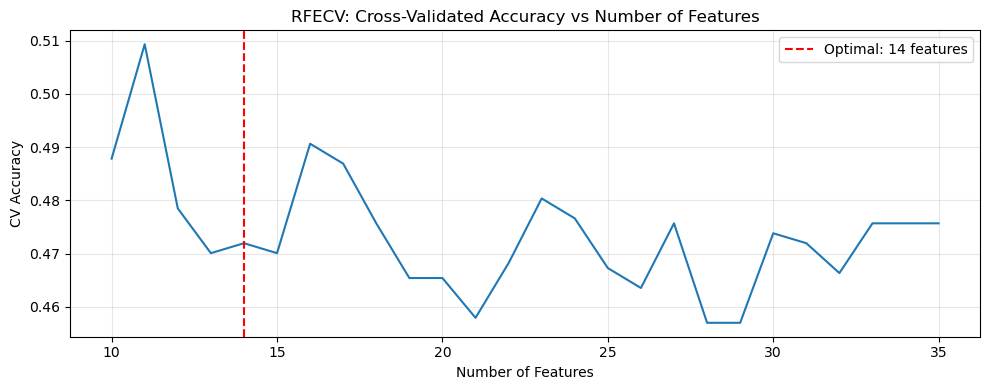


Selected features: ['KUP2', 'KLOW2', 'CORR_5', 'VSUMN_5', 'SUMP_10', 'VMA_10', 'ROC_20', 'QTLD_20', 'WVMA_20', 'ROC_30']...


In [5]:
# Scale features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=feature_cols)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=feature_cols)

# RFECV with XGBoost (Demo 16 style)
xgb_base = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                               random_state=42, eval_metric='logloss')

print("Running RFECV (this takes a few minutes)...")
rfecv = RFECV(estimator=xgb_base, step=5, cv=5, scoring='accuracy',
              min_features_to_select=10, n_jobs=-1)
rfecv.fit(X_train_scaled, y_train)

selected_mask = rfecv.support_
selected_features = [f for f, s in zip(feature_cols, selected_mask) if s]

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Best CV accuracy: {rfecv.cv_results_['mean_test_score'].max():.4f}")

# Plot RFECV curve
plt.figure(figsize=(10, 4))
n_features_range = range(rfecv.min_features_to_select, rfecv.min_features_to_select + len(rfecv.cv_results_['mean_test_score']))
plt.plot(n_features_range, rfecv.cv_results_['mean_test_score'])
plt.xlabel('Number of Features')
plt.ylabel('CV Accuracy')
plt.title('RFECV: Cross-Validated Accuracy vs Number of Features')
plt.axvline(x=rfecv.n_features_, color='red', linestyle='--', label=f'Optimal: {rfecv.n_features_} features')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSelected features: {selected_features[:10]}{'...' if len(selected_features) > 10 else ''}")

## 1.2 XGBoost Classification + Backtest

Same as Version 1 — XGBoost with all vs selected features, backtested with Backtrader.

In [6]:
X_train_sel = X_train_scaled[selected_features]
X_test_sel  = X_test_scaled[selected_features]

# XGBoost with ALL features
xgb_full = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                              random_state=42, eval_metric='logloss')
xgb_full.fit(X_train_scaled, y_train)
pred_full = xgb_full.predict(X_test_scaled)

# XGBoost with SELECTED features
xgb_sel = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                             random_state=42, eval_metric='logloss')
xgb_sel.fit(X_train_sel, y_train)
pred_sel = xgb_sel.predict(X_test_sel)

print("XGBoost with ALL features:")
print(classification_report(y_test, pred_full, digits=4))
print("XGBoost with SELECTED features:")
print(classification_report(y_test, pred_sel, digits=4))

acc_full = accuracy_score(y_test, pred_full)
acc_sel  = accuracy_score(y_test, pred_sel)
f1_full  = f1_score(y_test, pred_full)
f1_sel   = f1_score(y_test, pred_sel)
print(f"Accuracy: All={acc_full:.4f}  Selected={acc_sel:.4f}  Diff={acc_sel-acc_full:+.4f}")
print(f"F1 Score: All={f1_full:.4f}  Selected={f1_sel:.4f}  Diff={f1_sel-f1_full:+.4f}")

XGBoost with ALL features:
              precision    recall  f1-score   support

           0     0.4091    0.3214    0.3600       168
           1     0.5328    0.6250    0.5752       208

    accuracy                         0.4894       376
   macro avg     0.4709    0.4732    0.4676       376
weighted avg     0.4775    0.4894    0.4791       376

XGBoost with SELECTED features:
              precision    recall  f1-score   support

           0     0.4317    0.3571    0.3909       168
           1     0.5443    0.6202    0.5798       208

    accuracy                         0.5027       376
   macro avg     0.4880    0.4887    0.4853       376
weighted avg     0.4940    0.5027    0.4954       376

Accuracy: All=0.4894  Selected=0.5027  Diff=+0.0133
F1 Score: All=0.5752  Selected=0.5798  Diff=+0.0046


In [7]:
import backtrader as bt

class MLStrategy(bt.Strategy):
    params = (('predictions', None),)
    def __init__(self):
        self.pred_dict = self.params.predictions
        self.order = None
    def next(self):
        dt = self.data.datetime.date(0)
        pred = self.pred_dict.get(dt, 0)
        if self.order: return
        if pred == 1 and not self.position:
            size = int(self.broker.getcash() * 0.95 / self.data.close[0])
            if size > 0: self.order = self.buy(size=size)
        elif pred == 0 and self.position:
            self.order = self.close()
    def notify_order(self, order):
        if order.status in [order.Completed, order.Canceled, order.Margin, order.Rejected]:
            self.order = None

def run_backtest(ohlcv_df, predictions, initial_cash=INITIAL_CAPITAL):
    cerebro = bt.Cerebro()
    bt_df = pd.DataFrame({
        'open': ohlcv_df['Open'], 'high': ohlcv_df['High'],
        'low': ohlcv_df['Low'], 'close': ohlcv_df['Close'],
        'volume': ohlcv_df['Volume'], 'openinterest': 0
    }, index=ohlcv_df.index)
    cerebro.adddata(bt.feeds.PandasData(dataname=bt_df))
    pred_dict = {d.date() if hasattr(d, 'date') else d: int(p)
                 for d, p in zip(predictions.index, predictions.values)}
    cerebro.addstrategy(MLStrategy, predictions=pred_dict)
    cerebro.broker.setcash(initial_cash)
    cerebro.broker.setcommission(commission=0.001)
    cerebro.run()
    return cerebro.broker.getvalue()

test_ohlcv = raw.loc[X_test.index]
val_full = run_backtest(test_ohlcv, pd.Series(pred_full, index=X_test.index))
val_sel  = run_backtest(test_ohlcv, pd.Series(pred_sel, index=X_test.index))

print(f"=== Backtest Results (Initial: ${INITIAL_CAPITAL:,}) ===")
print(f"XGBoost (all {len(feature_cols)}):  Final=${val_full:,.2f}  Profit=${val_full-INITIAL_CAPITAL:+,.2f}")
print(f"XGBoost ({rfecv.n_features_} sel):  Final=${val_sel:,.2f}  Profit=${val_sel-INITIAL_CAPITAL:+,.2f}")
bh_value = INITIAL_CAPITAL * raw.loc[X_test.index[-1],'Close'] / raw.loc[X_test.index[0],'Close']
print(f"Buy & Hold:         Final=${bh_value:,.2f}  Profit=${bh_value-INITIAL_CAPITAL:+,.2f}")

=== Backtest Results (Initial: $10,000) ===
XGBoost (all 134):  Final=$10,086.10  Profit=$+86.10
XGBoost (14 sel):  Final=$10,482.97  Profit=$+482.97
Buy & Hold:         Final=$12,481.71  Profit=$+2,481.71


### 1.1 Findings

*(Results will be filled in based on actual output above.)*

---
## 1.2 Model Comparison

### MLP — TensorFlow/Keras (Demo 17 Style)

**Version 1** used sklearn's `MLPClassifier` (a black-box wrapper).
**Version 2** uses TensorFlow/Keras `Sequential` API (Demo 17):
- Explicit `Dense` layers with `Dropout` for regularization
- Training history with accuracy/loss curves
- More control over architecture and training

Architecture: `Input → Dense(128, ReLU) → Dropout(0.3) → Dense(64, ReLU) → Dense(1, sigmoid)`

MLP Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,241 (40.00 KB)

 Trainable params: 10,241 (40.00 KB)

 Non-trainable params: 0 (0.00 B)


=== MLP (Keras) ===
              precision    recall  f1-score   support

           0     0.4558    0.3988    0.4254       168
           1     0.5590    0.6154    0.5858       208

    accuracy                         0.5186       376
   macro avg     0.5074    0.5071    0.5056       376
weighted avg     0.5129    0.5186    0.5141       376



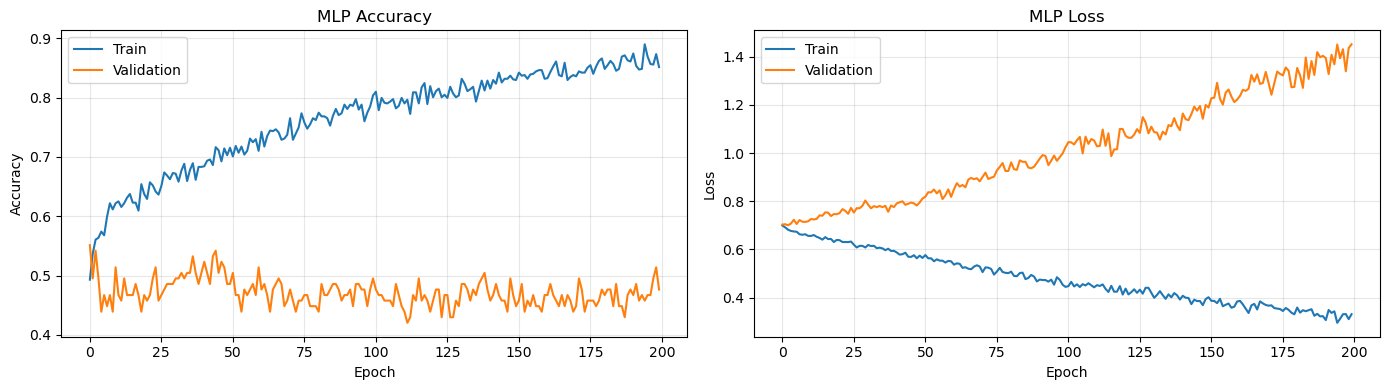

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM as KerasLSTM
from tensorflow.keras.optimizers import Adam

def plot_training_curves(history, model_name):
    """Plot accuracy and loss curves for a Keras model."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title(f'{model_name} Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title(f'{model_name} Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---- MLP with Keras (Demo 17 style) ----
mlp_model = Sequential([
    Input(shape=(len(selected_features),)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
mlp_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

print("MLP Architecture:")
mlp_model.summary()

history_mlp = mlp_model.fit(
    X_train_sel.values, y_train.values,
    epochs=200, batch_size=32,
    validation_split=0.1, verbose=0
)

# Evaluate
pred_mlp = (mlp_model.predict(X_test_sel.values, verbose=0) > 0.5).astype(int).flatten()

print(f"\n=== MLP (Keras) ===")
print(classification_report(y_test, pred_mlp, digits=4))

plot_training_curves(history_mlp, 'MLP')

### LSTM — TensorFlow/Keras (Demo 18 Style)

**Version 1** used PyTorch with 10-day lookback and manual training loop.
**Version 2** uses TensorFlow/Keras `LSTM` layer (Demo 18):
- 50-day lookback sequences (longer memory)
- MinMaxScaler normalization (standard for RNNs)
- Keras `.fit()` handles training loop automatically
- `return_sequences=False` → only use final hidden state for prediction

LSTM sequences — Train: (1020, 50, 14), Test: (326, 50, 14)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        13,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,051 (50.98 KB)

 Trainable params: 13,051 (50.98 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5022 - loss: 0.7090 - val_accuracy: 0.4216 - val_loss: 0.7214
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5272 - loss: 0.6917 - val_accuracy: 0.4412 - val_loss: 0.7152
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5381 - loss: 0.6852 - val_accuracy: 0.4706 - val_loss: 0.7146
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5664 - loss: 0.6791 - val_accuracy: 0.4706 - val_loss: 0.7226
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5795 - loss: 0.6756 - val_accuracy: 0.5098 - val_loss: 0.7140
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5926 - loss: 0.6726 - val_accuracy: 0.5098 - val_loss: 0.7629
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5937 - loss: 0.6720 - val_accuracy: 0.5000 - val_loss: 0.7087
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6078 - loss: 0.6630 - val_accuracy: 0.5294 - val_loss

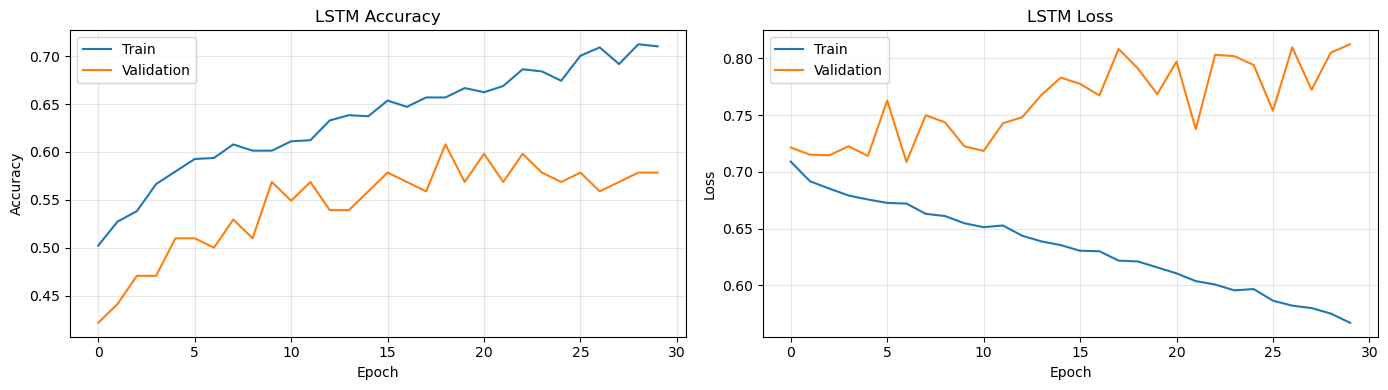

In [9]:
# ---- LSTM with Keras (Demo 18 style) ----
LOOKBACK = 50

# Create sequences from selected features
def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_sel.values, y_train.values, LOOKBACK)
X_test_seq, y_test_seq   = create_sequences(X_test_sel.values, y_test.values, LOOKBACK)

print(f"LSTM sequences — Train: {X_train_seq.shape}, Test: {X_test_seq.shape}")

# Build LSTM model (Demo 18 style)
lstm_model = Sequential([
    KerasLSTM(units=50, return_sequences=False, input_shape=(LOOKBACK, len(selected_features))),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=30, batch_size=32,
    validation_split=0.1, verbose=1
)

# Evaluate
pred_lstm = (lstm_model.predict(X_test_seq, verbose=0) > 0.5).astype(int).flatten()
print(f"\n=== LSTM (Keras, {LOOKBACK}-day lookback) ===")
print(classification_report(y_test_seq.astype(int), pred_lstm, digits=4))

plot_training_curves(history_lstm, 'LSTM')

### Transformer — TensorFlow/Keras (Demo 19 Style)

**Not in Version 1.** This is an additional model from Demo 19.

The Transformer uses **self-attention** instead of recurrence (LSTM) to capture temporal patterns.
Key components from Demo 19:
- **Time2Vector**: Custom layer that creates linear + periodic time embeddings
- **MultiHeadAttention**: 2-head attention mechanism that learns which time steps to focus on
- **Residual connections** + **LayerNormalization** for stable training
- **GlobalAveragePooling1D**: Aggregates across time steps for classification

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 50, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time2_vector_1      │ (None, 50, 28)    │      2,800 │ input_layer_3[0]… │
│ (Time2Vector)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 50, 42)    │          0 │ input_layer_3[0]… │
│ (Concatenate)       │                   │            │ time2_vector_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 50, 42)    │         84 │ concatenate[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 42)    │     10,986 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 50, 42)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 42)    │         84 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 42)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      2,752 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,771 (65.51 KB)

 Trainable params: 16,771 (65.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4662 - loss: 0.7104 - val_accuracy: 0.5294 - val_loss: 0.7267
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5163 - loss: 0.6950 - val_accuracy: 0.5392 - val_loss: 0.7350
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5305 - loss: 0.6925 - val_accuracy: 0.5392 - val_loss: 0.7143
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5305 - loss: 0.6903 - val_accuracy: 0.5392 - val_loss: 0.7770
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5534 - loss: 0.6842 - val_accuracy: 0.5294 - val_loss: 0.7541
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5643 - loss: 0.6832 - val_accuracy: 0.4510 - val_loss: 0.7486
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5501 - loss: 0.6809 - val_accuracy: 0.5196 - val_loss: 0.7741
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5359 - loss: 0.6837 - val_accuracy: 0.5000 - val_loss

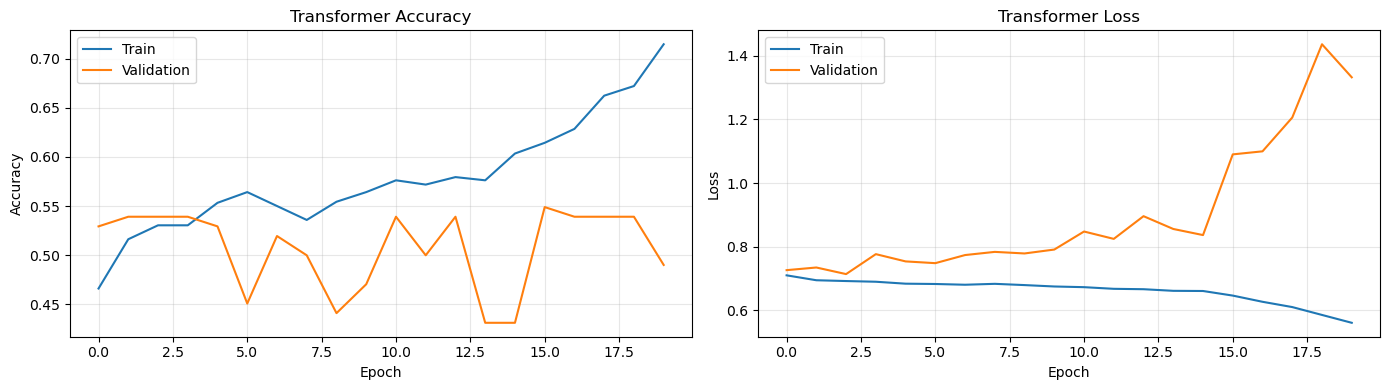

In [11]:
from tensorflow.keras import layers

# Time2Vector layer from Demo 19 (adapted for multi-feature input)
class Time2Vector(tf.keras.layers.Layer):
    def __init__(self, seq_len):
        super(Time2Vector, self).__init__()
        self.seq_len = seq_len

    def build(self, input_shape):
        n_features = input_shape[-1]
        self.weights_linear = self.add_weight(name='weight_linear', shape=(self.seq_len, n_features), initializer='uniform', trainable=True)
        self.bias_linear = self.add_weight(name='bias_linear', shape=(self.seq_len, n_features), initializer='uniform', trainable=True)
        self.weights_periodic = self.add_weight(name='weight_periodic', shape=(self.seq_len, n_features), initializer='uniform', trainable=True)
        self.bias_periodic = self.add_weight(name='bias_periodic', shape=(self.seq_len, n_features), initializer='uniform', trainable=True)

    def call(self, x):
        time_linear = self.weights_linear * x + self.bias_linear
        time_periodic = tf.math.sin(tf.multiply(x, self.weights_periodic) + self.bias_periodic)
        return tf.concat([time_linear, time_periodic], axis=-1)

def build_transformer_classifier(seq_len, n_features):
    input_layer = layers.Input(shape=(seq_len, n_features))
    time_embedding = Time2Vector(seq_len)(input_layer)
    x = layers.Concatenate()([input_layer, time_embedding])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    attention_output = layers.MultiHeadAttention(num_heads=2, key_dim=32)(x, x)
    x = layers.Add()([x, attention_output])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model(inputs=input_layer, outputs=x)

# Build and train Transformer
transformer = build_transformer_classifier(LOOKBACK, len(selected_features))
transformer.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
transformer.summary()

history_trans = transformer.fit(
    X_train_seq, y_train_seq,
    epochs=20, batch_size=32,
    validation_split=0.1, verbose=1
)

# Evaluate
pred_trans = (transformer.predict(X_test_seq, verbose=0) > 0.5).astype(int).flatten()
print(f"\n=== Transformer ===")
print(classification_report(y_test_seq.astype(int), pred_trans, digits=4))

plot_training_curves(history_trans, 'Transformer')

## Model Comparison

Now comparing **5 models** (Version 1 had 4):
XGBoost (all), XGBoost (selected), MLP (Keras), LSTM (Keras), Transformer

MODEL COMPARISON (Version 2) — Accuracy/F1 on common 326-day subset
           Model  Accuracy  F1 Score  Backtest Final ($)  Profit ($)
   XGBoost (all)  0.496933  0.575130        10086.099390   86.099390
XGBoost (14 sel)  0.521472  0.595855        10482.972029  482.972029
     MLP (Keras)  0.512270  0.580475         9041.436795 -958.563205
    LSTM (Keras)  0.509202  0.589744        10226.487174  226.487174
     Transformer  0.509202  0.617225        10026.502063   26.502063

Buy & Hold: $12,481.71 (profit: $+2,481.71)
Best model by profit: XGBoost (14 sel)


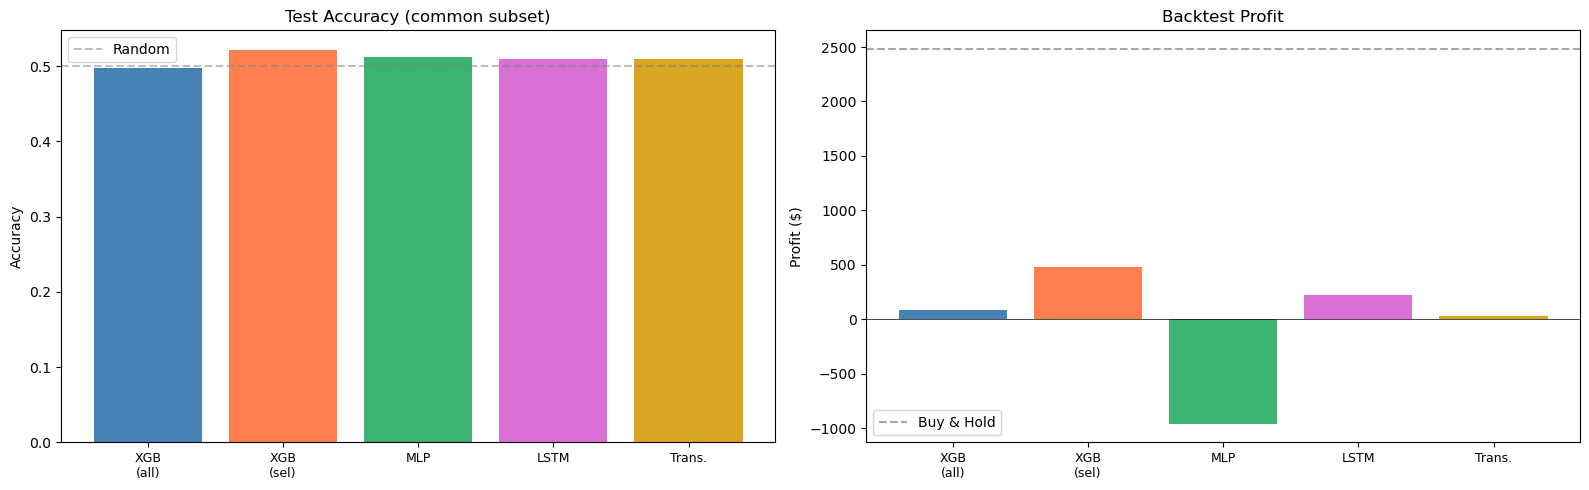

In [12]:
# ---- Fair comparison: evaluate all models on common test period ----
# LSTM/Transformer need LOOKBACK warmup days, so compare accuracy on the same subset
common_idx = X_test.index[LOOKBACK:]
y_test_common = y_test.loc[common_idx]

pred_full_common = pred_full[LOOKBACK:]
pred_sel_common  = pred_sel[LOOKBACK:]
pred_mlp_common  = pred_mlp[LOOKBACK:]

# Backtest all models over the full test period
val_mlp = run_backtest(test_ohlcv, pd.Series(pred_mlp, index=X_test.index))

# LSTM & Transformer: hold cash for first LOOKBACK days (no prediction available yet)
pred_lstm_full  = np.concatenate([np.zeros(LOOKBACK, dtype=int), pred_lstm])
pred_trans_full = np.concatenate([np.zeros(LOOKBACK, dtype=int), pred_trans])
val_lstm  = run_backtest(test_ohlcv, pd.Series(pred_lstm_full, index=X_test.index))
val_trans = run_backtest(test_ohlcv, pd.Series(pred_trans_full, index=X_test.index))

# Use common subset for accuracy/F1 so all models are compared on the same days
results = {
    'Model': ['XGBoost (all)', f'XGBoost ({rfecv.n_features_} sel)', 'MLP (Keras)', 'LSTM (Keras)', 'Transformer'],
    'Accuracy': [
        accuracy_score(y_test_common, pred_full_common),
        accuracy_score(y_test_common, pred_sel_common),
        accuracy_score(y_test_common, pred_mlp_common),
        accuracy_score(y_test_common, pred_lstm),
        accuracy_score(y_test_common, pred_trans)
    ],
    'F1 Score': [
        f1_score(y_test_common, pred_full_common),
        f1_score(y_test_common, pred_sel_common),
        f1_score(y_test_common, pred_mlp_common),
        f1_score(y_test_common, pred_lstm),
        f1_score(y_test_common, pred_trans)
    ],
    'Backtest Final ($)': [val_full, val_sel, val_mlp, val_lstm, val_trans],
    'Profit ($)': [v - INITIAL_CAPITAL for v in [val_full, val_sel, val_mlp, val_lstm, val_trans]]
}

results_df = pd.DataFrame(results)
print("=" * 90)
print(f"MODEL COMPARISON (Version 2) — Accuracy/F1 on common {len(y_test_common)}-day subset")
print("=" * 90)
print(results_df.to_string(index=False))
print(f"\nBuy & Hold: ${bh_value:,.2f} (profit: ${bh_value - INITIAL_CAPITAL:+,.2f})")
print(f"Best model by profit: {results_df.loc[results_df['Profit ($)'].idxmax(), 'Model']}")

# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(results['Model']))
colors = ['steelblue', 'coral', 'mediumseagreen', 'orchid', 'goldenrod']

axes[0].bar(x, results['Accuracy'], color=colors)
axes[0].set_xticks(x); axes[0].set_xticklabels(['XGB\n(all)', 'XGB\n(sel)', 'MLP', 'LSTM', 'Trans.'], fontsize=9)
axes[0].set_ylabel('Accuracy'); axes[0].set_title('Test Accuracy (common subset)')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
axes[0].legend()

axes[1].bar(x, results['Profit ($)'], color=colors)
axes[1].axhline(y=bh_value - INITIAL_CAPITAL, color='gray', linestyle='--', alpha=0.7, label='Buy & Hold')
axes[1].set_xticks(x); axes[1].set_xticklabels(['XGB\n(all)', 'XGB\n(sel)', 'MLP', 'LSTM', 'Trans.'], fontsize=9)
axes[1].set_ylabel('Profit ($)'); axes[1].set_title('Backtest Profit')
axes[1].legend(); axes[1].axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### 1.2 Findings

*(Results will be filled in based on actual output above.)*

---
## 1.3 SHAP Analysis

**Version 1** showed only the summary (beeswarm) plot.
**Version 2** adds a **waterfall plot** (Demo 16 style) that explains a single prediction
step by step — showing exactly how the model arrives at its prediction for one specific day.

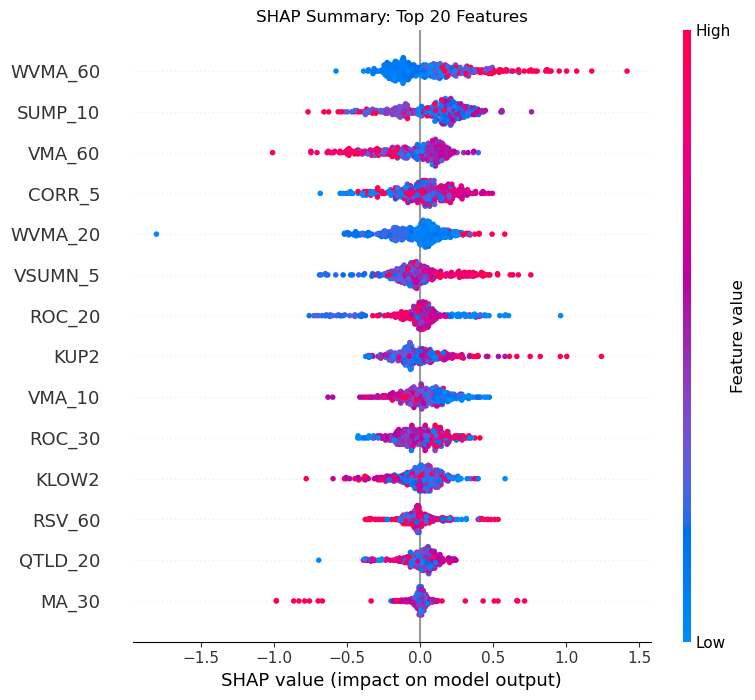

Explaining prediction for test day #0:
  Predicted: UP
  Actual:    UP


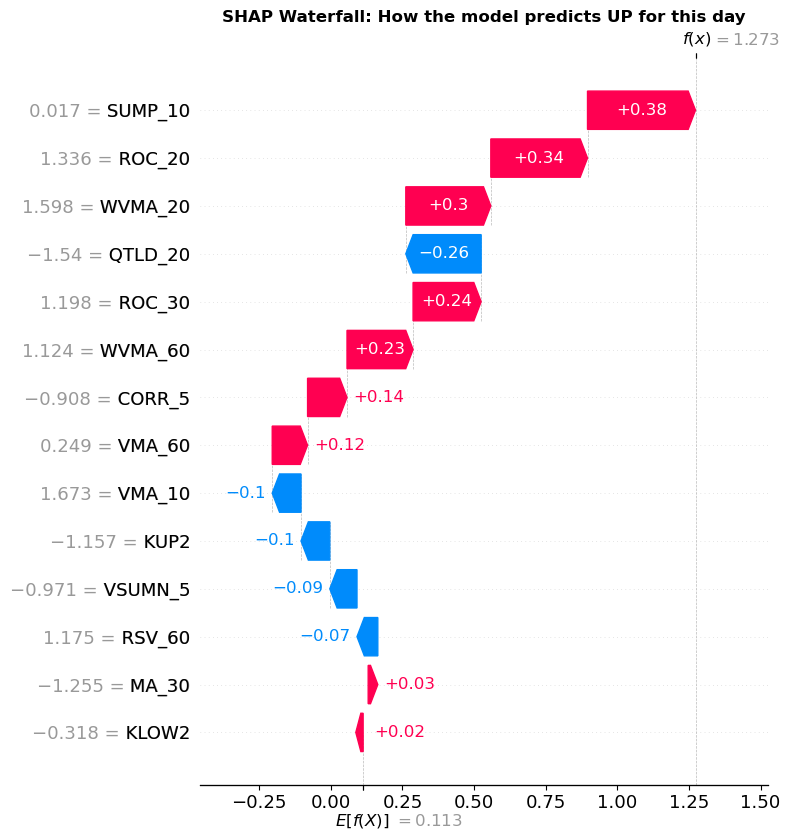


The waterfall shows:
- Starting from the base value (average prediction)
- Each feature pushes the prediction UP (red) or DOWN (blue)
- The final value is the model's output for this specific day


In [13]:
import shap

# TreeExplainer for XGBoost (selected)
explainer = shap.TreeExplainer(xgb_sel)
shap_values = explainer.shap_values(X_test_sel)

# Summary plot (same as v1)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sel, max_display=20, show=False)
plt.title("SHAP Summary: Top 20 Features")
plt.tight_layout()
plt.show()

# Waterfall plot for a single prediction (Demo 16 style)
sample_idx = 0
sample_pred = xgb_sel.predict(X_test_sel.iloc[[sample_idx]])[0]
sample_actual = y_test.iloc[sample_idx]
print(f"Explaining prediction for test day #{sample_idx}:")
print(f"  Predicted: {'UP' if sample_pred == 1 else 'DOWN'}")
print(f"  Actual:    {'UP' if sample_actual == 1 else 'DOWN'}")

plt.figure(figsize=(12, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test_sel.iloc[sample_idx],
        feature_names=X_test_sel.columns.tolist()
    ),
    max_display=15,
    show=False
)
plt.title(f'SHAP Waterfall: How the model predicts {"UP" if sample_pred == 1 else "DOWN"} for this day',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nThe waterfall shows:")
print("- Starting from the base value (average prediction)")
print("- Each feature pushes the prediction UP (red) or DOWN (blue)")
print("- The final value is the model's output for this specific day")

### 1.3 Findings

*(Results will be filled in based on actual output above.)*

---
## 2. Sentiment Analysis

**Version 1** used `pipeline()` wrapper (simple but less transparent).
**Version 2** uses raw `AutoTokenizer` + `AutoModelForSequenceClassification` (Demo 20 style):
- Explicitly tokenize text → run model → extract logits → softmax → score
- More transparent: you see every step of the inference pipeline
- Same distilroberta-finetuned-financial-news-sentiment-analysis model

We still use the Kaggle historical dataset for proper coverage of our training period.

In [14]:
import kagglehub
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import os

# ---- Step 1: Download Kaggle dataset ----
print("Downloading AAPL historical news from Kaggle...")
dataset_path = kagglehub.dataset_download("frankossai/apple-stock-aapl-historical-financial-news-data")
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
news_raw = pd.read_csv(os.path.join(dataset_path, csv_files[0]))
print(f"Loaded {len(news_raw)} articles")

# Parse dates
date_col = [c for c in news_raw.columns if any(k in c.lower() for k in ['date', 'time', 'publish'])][0]
headline_col = [c for c in news_raw.columns if any(k in c.lower() for k in ['title', 'headline'])][0]
news_raw['parsed_date'] = pd.to_datetime(news_raw[date_col], errors='coerce')
news_raw = news_raw.dropna(subset=['parsed_date', headline_col])
news_raw['date'] = news_raw['parsed_date'].dt.date

news_filtered = news_raw[
    (news_raw['parsed_date'] >= '2020-01-01') &
    (news_raw['parsed_date'] <= '2025-12-31')
].copy()
print(f"Articles in 2020-2025: {len(news_filtered)}")

# ---- Step 2: Load model (Demo 20 raw style) ----
MODEL_NAME = "mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis"
print(f"\nLoading tokenizer and model: {MODEL_NAME}")
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
mdl = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
label2id = mdl.config.label2id
pos_idx = label2id.get('positive', 2)
neg_idx = label2id.get('negative', 0)
print(f"Model loaded! Labels: {mdl.config.id2label}")

# Demo 20 style scoring function
def distilroberta_score(text):
    """Score a single headline. Returns P(positive) - P(negative) in [-1, +1]."""
    if not isinstance(text, str) or not text.strip():
        return 0.0
    inputs = tok(text[:512], return_tensors="pt", truncation=True)
    with torch.no_grad():
        logits = mdl(**inputs).logits.numpy().squeeze()
    # Numerically stable softmax
    shifted = logits - logits.max()
    p = np.exp(shifted) / np.exp(shifted).sum()
    return float(p[pos_idx] - p[neg_idx])

# ---- Step 3: Score all headlines ----
print(f"\nScoring {len(news_filtered)} headlines (this takes several minutes)...")
headlines = news_filtered[headline_col].fillna("").tolist()

# Process in chunks for progress reporting
sentiments = []
chunk_size = 1000
for i in range(0, len(headlines), chunk_size):
    chunk = headlines[i:i+chunk_size]
    chunk_scores = [distilroberta_score(h) for h in chunk]
    sentiments.extend(chunk_scores)
    print(f"  Processed {min(i+chunk_size, len(headlines))}/{len(headlines)}")

news_filtered = news_filtered.iloc[:len(sentiments)].copy()
news_filtered['sentiment'] = sentiments

print(f"\nDone! Sample headlines:")
print(news_filtered[[headline_col, 'date', 'sentiment']].head(10).to_string(index=False))

Loaded 29752 articles
Articles in 2020-2025: 29700

Loading tokenizer and model: mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded! Labels: {0: 'negative', 1: 'neutral', 2: 'positive'}

Scoring 29700 headlines (this takes several minutes)...
  Processed 1000/29700
  Processed 2000/29700
  Processed 3000/29700
  Processed 4000/29700
  Processed 5000/29700
  Processed 6000/29700
  Processed 7000/29700
  Processed 8000/29700
  Processed 9000/29700
  Processed 10000/29700
  Processed 11000/29700
  Processed 12000/29700
  Processed 13000/29700
  Processed 14000/29700
  Processed 15000/29700
  Processed 16000/29700
  Processed 17000/29700
  Processed 18000/29700
  Processed 19000/29700
  Processed 20000/29700
  Processed 21000/29700
  Processed 22000/29700
  Processed 23000/29700
  Processed 24000/29700
  Processed 25000/29700
  Processed 26000/29700
  Processed 27000/29700
  Processed 28000/29700
  Processed 29000/29700
  Processed 29700/29700

Done! Sample headlines:
                                                                                                           title       date  sentiment
     

Sentiment coverage: Overall=100.0%, Train=100.0%, Test=100.0%


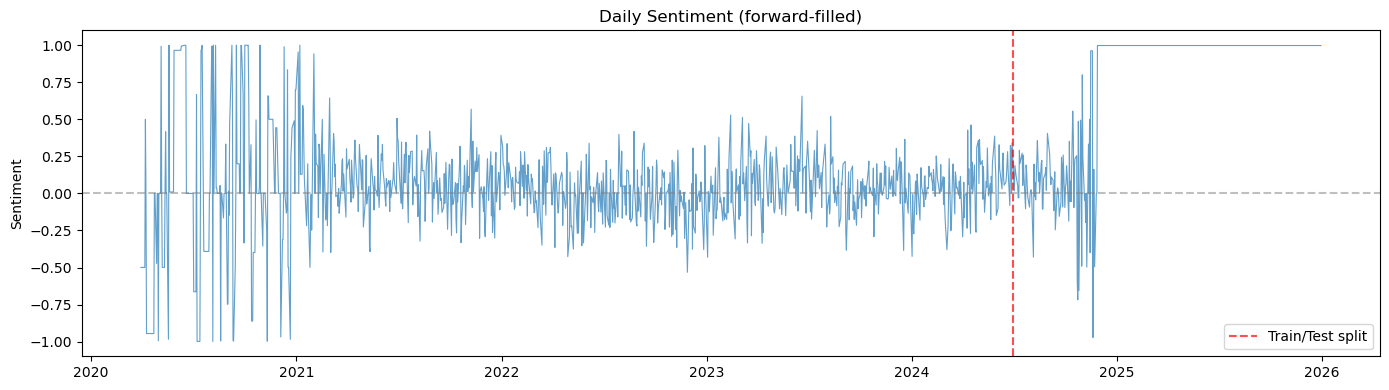


=== XGBoost with Sentiment ===
              precision    recall  f1-score   support

           0     0.4560    0.3393    0.3891       168
           1     0.5578    0.6731    0.6100       208

    accuracy                         0.5239       376
   macro avg     0.5069    0.5062    0.4996       376
weighted avg     0.5123    0.5239    0.5113       376


--- With vs Without Sentiment ---
Accuracy:  Without=0.5027  With=0.5239  Diff=+0.0213
F1 Score:  Without=0.5798  With=0.6100  Diff=+0.0302
Profit:    Without=$+482.97  With=$+1,597.16  Diff=$+1,114.19

Sentiment ranked #6 out of 15 features


In [15]:
# ---- Step 4: Create daily sentiment + retrain ----
daily_sent = news_filtered.groupby('date')['sentiment'].mean()
daily_sent.index = pd.to_datetime(daily_sent.index)

sentiment_feature = pd.Series(np.nan, index=df.index, name='sentiment')
for date in daily_sent.index:
    if date in sentiment_feature.index:
        sentiment_feature.loc[date] = daily_sent.loc[date]
sentiment_feature = sentiment_feature.ffill().fillna(0)

coverage = (sentiment_feature != 0).sum() / len(sentiment_feature) * 100
train_cov = (sentiment_feature.loc[:TRAIN_END] != 0).sum() / len(sentiment_feature.loc[:TRAIN_END]) * 100
test_cov = (sentiment_feature.loc[TRAIN_END:].iloc[1:] != 0).sum() / len(X_test) * 100
print(f"Sentiment coverage: Overall={coverage:.1f}%, Train={train_cov:.1f}%, Test={test_cov:.1f}%")

# Visualize
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sentiment_feature.index, sentiment_feature.values, alpha=0.7, linewidth=0.8)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=pd.Timestamp(TRAIN_END), color='red', linestyle='--', alpha=0.7, label='Train/Test split')
ax.set_title('Daily Sentiment (forward-filled)'); ax.set_ylabel('Sentiment'); ax.legend()
plt.tight_layout()
plt.show()

# Add sentiment and retrain
X_train_sent = X_train_sel.copy()
X_test_sent  = X_test_sel.copy()
X_train_sent['sentiment'] = sentiment_feature.loc[X_train_sel.index].values
X_test_sent['sentiment']  = sentiment_feature.loc[X_test_sel.index].values

xgb_sent = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                              random_state=42, eval_metric='logloss')
xgb_sent.fit(X_train_sent, y_train)
pred_sent = xgb_sent.predict(X_test_sent)

print("\n=== XGBoost with Sentiment ===")
print(classification_report(y_test, pred_sent, digits=4))

acc_sent = accuracy_score(y_test, pred_sent)
f1_sent  = f1_score(y_test, pred_sent)
val_sent = run_backtest(test_ohlcv, pd.Series(pred_sent, index=X_test.index))

print(f"\n--- With vs Without Sentiment ---")
print(f"Accuracy:  Without={acc_sel:.4f}  With={acc_sent:.4f}  Diff={acc_sent-acc_sel:+.4f}")
print(f"F1 Score:  Without={f1_sel:.4f}  With={f1_sent:.4f}  Diff={f1_sent-f1_sel:+.4f}")
print(f"Profit:    Without=${val_sel-INITIAL_CAPITAL:+,.2f}  With=${val_sent-INITIAL_CAPITAL:+,.2f}  Diff=${val_sent-val_sel:+,.2f}")

sent_rank = pd.Series(xgb_sent.feature_importances_, index=X_train_sent.columns).sort_values(ascending=False)
sentiment_rank = list(sent_rank.index).index('sentiment') + 1
print(f"\nSentiment ranked #{sentiment_rank} out of {len(sent_rank)} features")

### Section 2 Findings

*(Results will be filled in based on actual output above.)*